In [1]:
import copy
import joblib
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import os
import seaborn as sns
import shutil
import subprocess

from pathlib import Path
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import BallTree, KNeighborsClassifier

# Project 3 - Classifying Fishing Vessel Behaviour from AIS Tracking Data

#### Student 1 name: Steven Dodd
#### Student 1 ID: 99170727

#### Student 2 name: Caleb Otic
#### Student 2 ID: 25015998

#### Student 3 name: Shashwat Silwal
#### Student 3 ID: 25006980

#### Student 4 name: Aditdeep Singh Sandhu
#### Student 4 ID: 25012027

---

## Introduction

**Background**

[Global Fishing Watch](https://globalfishingwatch.org/) (GFW) is a non-profit organisation that monitors global fishing activity using vessel tracking data transmitted via the Automatic Identification System (AIS). Commercial fishing vessels are legally required to broadcast their position, speed, and heading at regular intervals. GFW collects and makes available this data, as part of its mission of advancing ocean governance through increased transparency of human activity at sea.

**Dataset**

This notebook uses GFW's publicly released training dataset, comprising an anonymised set of AIS position pings collected from commercial fishing vessels between 2012 and 2016. This dataset forms the basis for the models within this notebook.

**Research Focuses**

- Q1 - Can changes in speed and direction predict fishing activity?
- Q2 - Does including gear type as a feature improve fishing activity detection across models?
- Q1 & Q2 Findings:
  - [kNN Classification](#kNN-Classification)
  - [Logistic Regression](#Logistic-Regression)
  - [Random Forest Classification](#Random-Forrest-Classification)
  - [Naive Bayes Classification](#Naive-Bayes-Classification)
- [Q3 - Evaluating Behavioral Predictors for Geospatial Classification](#Q3---Evaluating-Behavioral-Predictors-for-Geospatial-Classification)


**Data Sources**

- [Global Fishing Watch Training Data](https://github.com/GlobalFishingWatch/training-data)
- [Upply Sea Ports](https://opendata.upply.com/seaports)


## Configuration

- Global variables used throughout notebook

In [2]:
# If set, this notebook will clone the Global Fishing Watch training-data GitHub repo
# and build the starting dataset. This process takes around 5-6 hours, so is disabled by default.
# Because of this, the dataset this process produces is included in the submission.
CLONE_AND_BUILD_RAW_DATASET_FROM_SOURCE = False

# Initial/raw dataset, before feature engineering
RAW_DATASET_FILENAME = Path('gfw.parquet')

# The "main" dataset containing engineered features. Generated by this notebook and used with modelling
DATASET_FILENAME = Path('gfw_features.parquet')

# Whether to regenerate the engineered features dataset if it already exists
OVERWRITE_EXISTING_FEATURES_DATASET = False

# Whether to export final models to disk (used for assisting with Streamlit app development)
EXPORT_MODELS = False

## Data acquisition and preparation

- <mark>**Optional**</mark> step to retrieve and build the initial dataset file **gfw.parquet**
- Because this process takes approximate 5-6 hours and involves large file downloads, gfw.parquet is included in the project submission and this step is skipped by default. It can be enabled by setting `CLONE_AND_BUILD_RAW_DATASET_FROM_SOURCE = True`
- **Warning:** This process has been tested on Windows only
- **Requirements:** git, git-lfs, Python 3.12+ on PATH

**High level summary**

- Clone Global Fishing Watch's "training-data" repo from GitHub
- Run scripts within repo to apply `is_fishing` labels to all raw AIS pings
- Select rows where `is_fishing` was successfully labelled (excludes ~98% of rows where fishing status was unknown)
- Further select rows for the vessel types that have good overall represenataion: Longliners, Trawlers, Purse seines, Fixed gear
- Clean data (remove duplicates based on vessel ID and time)
- Save result as `gfw.parquet` and clean up

In [3]:
if not CLONE_AND_BUILD_RAW_DATASET_FROM_SOURCE:
    print(f"Skipping clone-and-build dataset (existing '{RAW_DATASET_FILENAME}' will be used)")
else:
    GFW_GITHUB_REPO = 'https://github.com/GlobalFishingWatch/training-data'
    CLEANUP_AFTER_CLONE_AND_BUILD = True
    CLONE_DIR  = Path('training-data')        # GitHub repo will be cloned here
    VENV_DIR   = CLONE_DIR / '.venv_temp'     # Virual environment will be set inside
    PATCH_FILE = Path('windows_compatibility.patch')  # Must exist alongside notebook

    print("WARNING: This full process takes several hours.")
    print("Requires: git, git-lfs, Python 3.12+ on PATH")

    # Helper to run shell commands and optionally stream real time output for the long running step
    def run(cmd, cwd=None, shell=True, stream=False):
        process = subprocess.Popen(
            cmd, cwd=cwd, shell=shell,
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
            text=True, bufsize=1
        )

        output_lines = []
        for line in process.stdout:
            output_lines.append(line.rstrip())
            if stream:
                print(line, end='')

        process.wait()
        if process.returncode != 0:
            raise RuntimeError(
                f"Command failed (exit code {process.returncode}): {cmd}\n"
                f"Last output:\n{'\n'.join(output_lines[-5:])}"  # show the last 5 lines
            )

        if not stream:
            print("  Done") # ({len(output_lines)} lines of output)")

    try:
        # STEP 1: Git LFS
        print("- " * 30)
        print("Step 1: Installing Git LFS")
        run("git lfs install")

        # STEP 2: Clone 
        print("- " * 30)
        print("Step 2: Cloning Global Fishing Watch training-data repo (takes a few minutes)")
        if CLONE_DIR.exists():
            print(f"  {CLONE_DIR} already exists - skipping clone")
        else:
            run(f"git clone {GFW_GITHUB_REPO} {CLONE_DIR}")

        # STEP 3: Virtual environment 
        print("- " * 30)
        print("Step 3: Creating virtual environment")
        if VENV_DIR.exists():
            print(f"  {VENV_DIR} already exists - skipping creation, also assuming dependencies exist")
        else:
            pip = str(Path.cwd() / VENV_DIR / "Scripts" / "pip.exe")
            run(f"python -m venv {VENV_DIR}")
            print("  Installing dependencies")
            run(f'"{pip}" install -r requirements.txt', cwd=CLONE_DIR)      
        python = Path(VENV_DIR / "Scripts" / "python.exe")

        # STEP 4: Apply patch 
        print("- " * 30)
        print("Step 4: Applying Windows compatibility patch")
        if not PATCH_FILE.exists():
            raise FileNotFoundError(f"Patch file not found: {PATCH_FILE}")
        dest_path_file = Path(CLONE_DIR / PATCH_FILE.name)
        if dest_path_file.exists():
            print("  Patch file has previously been copied into repo, will not re-apply")
        else:
            shutil.copy(PATCH_FILE, CLONE_DIR / PATCH_FILE.name)
            run(f"git apply {PATCH_FILE.name}", cwd=CLONE_DIR)

        # STEP 5: Merge AIS and ranges 
        print("- " * 30)
        print("Step 5: Merging AIS tracks with fishing labels (several hours)")
        csv_files = list((CLONE_DIR / 'data' / 'time-ranges').glob('*.csv'))
        csv_args = ' '.join(f'"{f.relative_to(CLONE_DIR)}"' for f in csv_files)
        Path(CLONE_DIR, "data", "merged").mkdir(parents=True, exist_ok=True)
        run(
            f'"{python.resolve()}" scripts/merge_ais_and_ranges_win.py '
            f'--source-paths {csv_args} '
            f'--point-source-path data/tracks '
            f'--dest-path data/merged',
            stream=True,
            cwd=CLONE_DIR
        )

        # STEP 6: Split by class
        print("- " * 30)
        print("Step 6: Splitting merged data by gear type (takes a few minutes)")
        Path(CLONE_DIR, "data", "labeled").mkdir(parents=True, exist_ok=True)
        run(
            f'"{python.resolve()}" scripts/split_by_class_win.py '
            f'--classes data/mmsis.csv '
            r'--output_template data/merged/{source}_{cls}.npz '
            f'data/merged/*.npz',
            stream=True,
            cwd=CLONE_DIR
        )

        # STEP 7: combine and clean selected split files into final dataset
        print("- " * 30)
        print("Step 7: Cleaning and combining selected split files into final dataset")                
        
        # Define which files are to be loaded, plus associated gear type and data source labels
        # These selections are based on prior inspection.
        # Excluded gear types: Unknown, Pole_and_line, Trollers (too few samples relative to other categories)
        # Excluded data sources, false_positives
        files_config = [
            # (filename, gear_label, source)
            ('kristina_longliner_Drifting_longlines.npz', 'longliner',    'kristina'),
            ('kristina_trawl_Trawlers.npz',               'trawler',      'kristina'),
            ('kristina_ps_Purse_seines.npz',              'purse_seine',  'kristina'),
            ('kristina_longliner_Fixed_gear.npz',         'fixed_gear',   'kristina'),
            ('alex_crowd_sourced_Drifting_longlines.npz', 'longliner',    'crowd_sourced'),
            ('alex_crowd_sourced_Purse_seines.npz',       'purse_seine',  'crowd_sourced'),
            ('pybossa_project_3_Trawlers.npz',            'trawler',      'dalhousie'),
            ('pybossa_project_3_Drifting_longlines.npz',  'longliner',    'dalhousie'),
            ('pybossa_project_3_Purse_seines.npz',        'purse_seine',  'dalhousie'),
            ('pybossa_project_3_Fixed_gear.npz',          'fixed_gear',   'dalhousie')
        ]

        # Load each file into a DataFrame, then combine
        combined = []
        print('Processing selected files from "Split by class" step (based on prior inspection)')
        for filename, gear_label, source in files_config:
            full_filename = Path(CLONE_DIR / 'data' / 'merged', filename)
            if not os.path.exists(full_filename):        
                raise RuntimeError(f"Missing file: {filename}\n")
            
            # Read and extract data values
            with np.load(full_filename) as data:
                df = pd.DataFrame(data['x'])
            
            # Exclude unlabelled rows
            raw_rows = len(df)
            df = df[df['is_fishing'] != -1.0]
            labelled_rows = len(df)    
            print(f"{filename:50s} raw: {raw_rows:>11,} labelled: {labelled_rows:>8,} "
                f"({labelled_rows/raw_rows:.1%})")
            
            # Set gear (vessel) type and data source columns
            df['gear_type'] = gear_label
            df['source'] = source    
            combined.append(df)
        combined = pd.concat(combined, ignore_index=True)

        # Convert timestamp to a datetime
        combined['datetime'] = pd.to_datetime(combined['timestamp'], unit='s')
        combined = combined.drop(columns=['timestamp'])

        # Deduplicate on vessel + timestamp (keep first occurrence)
        df_clean = combined.drop_duplicates(subset=['mmsi', 'datetime']).copy()
        print(f"Rows after dedup:  {len(df_clean):,}")

        # Finalise data types
        df_clean = df_clean.astype({
            'mmsi':                'int64',
            'distance_from_shore': 'float32',
            'distance_from_port':  'float32',
            'speed':               'float32',
            'course':              'float32',
            'lat':                 'float32',
            'lon':                 'float32',
            'is_fishing':          'int8',
            'gear_type':           'category',
            'source':              'category',
        })
        # Using `int64` above stripped the .0, but what we really want is a string
        df_clean['mmsi'] = df_clean['mmsi'].astype(str)

        # Display a few stats
        print("\nis_fishing distribution:")
        print(combined['is_fishing'].value_counts(normalize=True).round(2))
        print("\nGear type distribution:")
        print(combined['gear_type'].value_counts())
        print("\nSource distribution:")
        print(combined['source'].value_counts())

        # Save dataset
        print(f"\nFinal dataset: {len(df_clean):,} rows, {df_clean['mmsi'].nunique()} unique vessels")
        df_clean.to_parquet(RAW_DATASET_FILENAME, index=False)
        print(f"\nSaved final dataset to: {RAW_DATASET_FILENAME}")        

        # STEP 8: cleanup
        print("- " * 30)
        print("Step 8: Removing cloned github repo and all other intermediate files")
        if CLEANUP_AFTER_CLONE_AND_BUILD:
            print(f"  For any errors deleting file (e.g. file locks), {CLONE_DIR}/ is safe to delete manually")
            def remove_readonly(func, path, excinfo):
                os.chmod(path, stat.S_IWRITE)
                func(path)
            shutil.rmtree(CLONE_DIR, onerror=remove_readonly)
        else:
            print("  CLEANUP_AFTER_CLONE_AND_BUILD = False, skipping step")
            print("  It is safe to manually delete the training-data/ directory")

        print("- " * 30)
        print("Clone and build complete")

    except Exception as e:
        print(f"\nERROR: {e}")
        raise

Skipping clone-and-build dataset (existing 'gfw.parquet' will be used)


## Feature Engineering

- Read in initial dataset `gfw.parquet`and secondary dataset `UPPLY-SEAPORTS.xlsx`
- Engineer and add new features
- Save results to `gfw_features.parquet`

Starting features present in the initial dataset:

- `mmsi`  Vessel identifier
- `distance_from_shore` Metres
- `distance_from_port` Metres
- `speed` Knots
- `course` Degrees (0-360, direction of travel)
- `lat` / `lon` Position
- `is_fishing` 1=Yes, 0=No
- `gear_type` Category (longliner, fixed_gear, purse_seine, trawler)
- `source` Category (Who recorded this data)
- `datetime` (of AIS ping)

Engineered features:

- `month` (1 to 12)
- `season` (0 to 3)
- `season_str` String mapping of `season` (for convenience)
- `trip_id_local` Identifies each distinct trip undertaken for a paritcular vessel (`mmsi`)
- `trip_id_global` Uniquely identifies all distinct trips globally (concatenation: `mmsi`, "_", `trip_id_local`)
- `speed_change_rate`  Acceleration/deceleration (knots per minute, clipped to $\pm$ 5)
- `speed_mean_N`  Recent average speed, based on last N pings
- `speed_std_N`  Speed variability over last N pings (fishing signature)
- `course_change_rate`  Turning rate (degrees per minute, clipped to $\pm$ 30),
- `course_std_N`  Turning variability over last N pings (encircling signature)

Enriched features from Upply Seaports file:

- `nearest_port_code` Seaport unique identifier
- `nearest_port_country` Seaport ISO 3166-1 2-letter country code
- `nearest_port_dist` Calculated distance to seaport
- `nearest_port_name` Seaport official name
- `nearest_port_zone` Seaport region location 5-character code

In [4]:
if DATASET_FILENAME.exists() and not OVERWRITE_EXISTING_FEATURES_DATASET:
    print(f"Skipping feature engineering (target file '{DATASET_FILENAME}' already exists)")

else:
    # Constants 
    NEW_TRIP_THRESHOLD = 3600 * 4  # elapsed time between pings before a new trip is assumed (4 hours)
    MAX_SPEED_RATE_CHANGE = 5      # speed change rates are clipped to +/- this
    MAX_COURSE_RATE_CHANGE = 30    # course change rates are clipped to +/- this
    ROLLING_LAST_N = [5, 10, 30]   # Number of rows to use to calculate rolling values (speed, course)
    
    df = pd.read_parquet(RAW_DATASET_FILENAME)
    
    # Month (int32, 1-12)
    df['month'] = df['datetime'].dt.month
    
    # Add season code (these are for northern hemisphere: 0=Winter, 1=Spring, 2=Summer, 3=Autumn)
    month_season_map = {1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2, 9:3, 10:3, 11:3, 12:0}
    df['season'] = df['month'].map(month_season_map)
    
    # Flip season if southern hemisphere
    sh_mask = df['lat'] < 0
    df.loc[sh_mask, 'season'] = (df.loc[sh_mask, 'season'] + 2) % 4
    
    # Season string is just for clarity really
    season_str_map = {0:'Winter', 1:'Spring', 2:'Summer', 3:'Autumn'}
    df['season_str'] = df['season'].map(season_str_map)
    
    # Rolling window per trip for last N (`window`) pings. Applies per unique trip so expects `trip_id_global` to have been set
    def trip_rolling_value(df, col, window, func):
        return (
            df.groupby('trip_id_global')[col]
            .transform(lambda x: getattr(x.rolling(window, min_periods=1), func)())
            )
    
    # Calculate the time delta between consecutive pings per vessel (in seconds)
    df = df.sort_values(['mmsi', 'datetime'])
    df['time_delta_s'] = (df.groupby('mmsi')['datetime'].diff().dt.total_seconds())
    
    # Look for time gaps between pings that exceed some threshold, we assume such gaps represent the start of a new trip for that vessel
    # Also, the very first row for each mmsi/datetime grouping will have time delta of NaN, which is also a new trip start
    df['new_trip_marker'] = ( (df['time_delta_s'].isna() ) | (df['time_delta_s'] > NEW_TRIP_THRESHOLD) )
    print(f'Number of unique trips identfied: {(df['new_trip_marker'][df['new_trip_marker']]).count():,}')
    
    # For each vessel, add a locally unique trip id, and also combine with mmsi to create a globally unique trip id
    df['trip_id_local'] = df.groupby('mmsi')['new_trip_marker'].cumsum()
    df['trip_id_global'] = df['mmsi'].astype(str) + "_" + df['trip_id_local'].astype(str)
    
    # Make sure data is sorted as required for what follows
    df = df.sort_values(['trip_id_global', 'datetime'])
    
    # Speed features
    
    # Raw and normalised change in speed between pings (with capping to prevent extreme values)
    df['speed_change'] = df.groupby('trip_id_global')['speed'].diff()
    df['speed_change_rate'] = (df['speed_change'] / (df['time_delta_s'] / 60)).clip(-MAX_SPEED_RATE_CHANGE, MAX_SPEED_RATE_CHANGE)
    
    # Course features
    
    def finalise_course_change(raw_change):
        # Deal with the fact course change can cycle through 0 degrees, meaning just using `diff()` is inadequate
        if pd.isna(raw_change):
            return raw_change
        if raw_change > 180:   # e.g. 1 -> 359 appears as +358, corrected to -2 (small left turn)
            return raw_change - 360
        if raw_change < -180:  # e.g. 359 -> 1 appears as -358, corrected to +2 (small right turn)
            return raw_change + 360
        return raw_change
    
    # Raw and normalised change in course between pings (with capping to prevent extreme values)
    df['course_change'] = df.groupby('trip_id_global')['course'].diff().apply(finalise_course_change)
    df['course_change_rate'] = (df['course_change'] / (df['time_delta_s'] / 60)).clip(-MAX_COURSE_RATE_CHANGE, MAX_COURSE_RATE_CHANGE)
    
    # Calculate rolling values for speed and course
    for n in ROLLING_LAST_N:
        df[f'speed_mean_{n}'] = trip_rolling_value(df, 'speed', n, 'mean') # average
        df[f'speed_std_{n}'] = trip_rolling_value(df, 'speed', n, 'std')   # speed variability
        df[f'course_std_{n}'] = trip_rolling_value(df, 'course_change', n, 'std')  # course change variability
    
    # The first ping for each trip can't have delta-related values
    cols = ['time_delta_s', 'speed_change', 'speed_change_rate']
    df.loc[df['new_trip_marker'], cols] = np.nan
    
    # Converting gear_type into separate columns (0 or 1)
    df['vessel_gear_type'] = df['gear_type']  # also preserve orignal categoric value
    df = pd.get_dummies(df, columns=['gear_type'], drop_first=False)
    
    # Drop intermediate columns not needed for modelling
    intermediate_features = ['new_trip_marker', 'time_delta_s', 'speed_change', 'course_change']
    df = df.drop(columns=intermediate_features)
    
    # Drop the engineered features that may have NaNs
    engineered_features = ['speed_change_rate', 'course_change_rate'] # , 'speed_mean_5', 'speed_std_5', 'course_std_5']
    for feat in ['speed_mean', 'speed_std', 'course_std']:
        engineered_features.extend(f'{feat}_{n}' for n in ROLLING_LAST_N)
    rows_before = len(df)
    df = df.dropna(subset=engineered_features)
    rows_after = len(df)
    print(f"Dropped {rows_before - rows_after:,} rows with NaN engineered features " f"({(rows_before-rows_after)/rows_before:.2%} of data)")
    print(f"Remaining rows: {rows_after:,}")
    print()

    # Secondary data source - Upply seaports Excel file
    upply_filename = Path('UPPLY-SEAPORTS.xlsx')
    print(f"Integrating '{upply_filename}'")
    df_seaports = pd.read_excel(upply_filename, sheet_name='Ports')

    # Build a BallTree on Upply seaport coordinates using haversine metric
    ports_rad = np.radians(df_seaports[['latitude', 'longitude']].values)
    tree = BallTree(ports_rad, metric='haversine')
    
    # ref: https://stackoverflow.com/a/55464751
    # Find nearest port (k=1) for every row, based on its AIS ping's lat/long co-ords
    pings_rad = np.radians(df[['lat', 'lon']].values)
    distances, indices = tree.query(pings_rad, k=1)
    
    # Force results into 1D (ok since k=1)
    distances = np.squeeze(distances)
    indices = np.squeeze(indices)
    
    # Convert radians to km and add columns to primary dataset
    EARTH_RADIUS = 6371 # km
    df['nearest_port_dist'] = distances * EARTH_RADIUS
    df['nearest_port_country'] = df_seaports['country_code'].iloc[indices].values
    df['nearest_port_zone'] = df_seaports['zone_code'].iloc[indices].values
    df['nearest_port_name'] = df_seaports['name'].iloc[indices].values
    df['nearest_port_code'] = df_seaports['code'].iloc[indices].values        
    
    # Save
    df.to_parquet(DATASET_FILENAME, index=False)
    print(f"Saved GFW + engineered features dataset to '{DATASET_FILENAME}'")

Number of unique trips identfied: 24,336
Dropped 43,885 rows with NaN engineered features (7.04% of data)
Remaining rows: 579,566

Integrating 'UPPLY-SEAPORTS.xlsx'
Saved GFW + engineered features dataset to 'gfw_features.parquet'


## kNN Classification

### Q1 - Can changes in the speed of vessel and direction predict whether a vessel is engaged in a fishing activity?

In [5]:
#Load the engineered fishing dataset
df = pd.read_parquet(DATASET_FILENAME)


#Split data by trip ID
trips = df["trip_id_global"].unique()
train_trips, test_trips = train_test_split(trips, test_size=0.2, random_state=42)
train = df[df["trip_id_global"].isin(train_trips)]
test = df[df["trip_id_global"].isin(test_trips)]

In [6]:
base_features = [
    'speed_change_rate',
    'course_change_rate',
    'speed_mean_10',
    'speed_std_10',
    'course_std_10'
]

In [7]:
X_train = train[base_features]
X_test = test[base_features]
y_train = train["is_fishing"]
y_test = test["is_fishing"]


# Remove missing values
train_data = pd.concat([X_train,y_train], axis=1).dropna()
test_data = pd.concat([X_test,y_test], axis=1).dropna()


X_train = train_data[base_features]
y_train = train_data["is_fishing"]
X_test = test_data[base_features]
y_test = test_data["is_fishing"]


# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
#kNN Classification
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [9]:
preds = knn.predict(X_test_scaled)

# Print Results 
print("Classification Report:")
print(classification_report( y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix( y_test, preds))

print(f"F1 Score: {f1_score(y_test, preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84     61750
           1       0.82      0.82      0.82     55773

    accuracy                           0.83    117523
   macro avg       0.83      0.83      0.83    117523
weighted avg       0.83      0.83      0.83    117523

Confusion Matrix:
[[51833  9917]
 [10035 45738]]
F1 Score: 0.821


Interpretation: The kNN lassifcication model above achieved an F1 score of 0.821, indicating a strong performance in predicting fishing activity. The F1 score measures the balance between precision and call, meaning that the model performs well at both correctly identifying fishing events and avoiding incorrect classifications. Suggesting that changes in vessel speed and direction contains an impactful information for distinguishing fishing from non-fishing.

### Q2 - Does including gear type as a feature improve fishing activity detection across models?

In [10]:
#Find all gear_type columns
gear_cols = [c for c in df.columns if c.startswith('gear_type')]

#Add gear_type features together with the original movement features
X_train_gear = train[base_features + gear_cols]
X_test_gear = test[base_features + gear_cols]

#Standardise
scaler = StandardScaler()
X_train_gear_scaled = scaler.fit_transform(X_train_gear)
X_test_gear_scaled = scaler.transform(X_test_gear)

if EXPORT_MODELS:
    # Keep a copy of this scalar, which is needed by the final model export cell
    scaler_gear_fitted_copy = copy.deepcopy(scaler)

#kNN Model
knn_gear = KNeighborsClassifier(n_neighbors=5)

#Train the model
knn_gear.fit(X_train_gear_scaled, y_train)

KNeighborsClassifier()

In [11]:
#Predict fishing activity using tetsing data
preds = knn_gear.predict(X_test_gear_scaled)

# Print Results
print("Classification Report:")
print(classification_report( y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix( y_test, preds))

print(f"F1 Score: {f1_score(y_test,preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     61750
           1       0.85      0.85      0.85     55773

    accuracy                           0.86    117523
   macro avg       0.86      0.86      0.86    117523
weighted avg       0.86      0.86      0.86    117523

Confusion Matrix:
[[53581  8169]
 [ 8300 47473]]
F1 Score: 0.852


Interpretation: The kNN model achieved an accuracy of 86% and an F1 score of 0.852, indicates that strong predictive performance in identifying fishing activity. Compared to Q1, adding gear type improves the model performance. Accuracy increased from 83% to 86%, while the F1 score increased from 0.821 to 0.852. The improvement in F1 score indicates that there are better overall balance between precission and recall when detecting fishing activity. This suggests that gear type provides additional predictive information beyond vessel speed and directional changes alone.

## Logistic Regression

### Q1 - Can changes in the speed of vessel and direction predict whether a vessel is engaged in a fishing activity?

In [12]:
#Logistic Regression
logreg = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [13]:
# Predict
preds = logreg.predict(X_test_scaled)


# Print results
print("Classification Report:")
print(classification_report(y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))


print(f"F1 Score: {f1_score(y_test,preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.86      0.73     61750
           1       0.75      0.47      0.58     55773

    accuracy                           0.67    117523
   macro avg       0.69      0.66      0.65    117523
weighted avg       0.69      0.67      0.66    117523

Confusion Matrix:
[[52847  8903]
 [29637 26136]]
F1 Score: 0.576


Interpretation: 
    The Logistic Regression model above used to investigate whether changes in vessel speed and direction predict fishing activity. Looking in the results, LR achieved a 0.576 F1 score, indicating a moderate predictive performance. Even though this showed a high precision, recall for fishing was low, meaning that more than half of actual fishing events were missed. The confusion matrix further demonstrates the LR struggle to identify fishing behaviur accurately.

### Q2 - Does including gear type as a feature improve fishing activity detection across models?

In [14]:
gear_cols = [c for c in df.columns if c.startswith('gear_type')]
X_train_gear = train[base_features + gear_cols]
X_test_gear = test[base_features + gear_cols]

scaler = StandardScaler()
X_train_gear_scaled = scaler.fit_transform(X_train_gear)
X_test_gear_scaled = scaler.transform(X_test_gear)

logreg_gear = LogisticRegression(max_iter = 1000, class_weight = 'balanced')

logreg_gear.fit(X_train_gear_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [15]:
# Predict
preds = logreg_gear.predict(X_test_gear_scaled)


# Print results
print("Classification Report:")
print(classification_report(y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))


print(f"F1 Score: {f1_score(y_test,preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.57      0.64     61750
           1       0.62      0.78      0.69     55773

    accuracy                           0.67    117523
   macro avg       0.68      0.67      0.67    117523
weighted avg       0.68      0.67      0.67    117523

Confusion Matrix:
[[35301 26449]
 [12492 43281]]
F1 Score: 0.690


Interpretation: The model above shows that there is an accuracy of 67% and F1 score of 0.690. Compared to the Q1, this models shows that including gear type substantially improved fishing activity detection. Accuracy stayed the same at 67%, but the F1 score jumps from 0.576 to 0.69, indicating a stronger balance between precision and recall. Most notably on recall for fishing activity increased from 47% to 78%, meaning that model became much more effective at identifying actual fishing events.

## Random Forrest Classification

### Q1 - Can changes in the speed of vessel and direction predict whether a vessel is engaged in a fishing activity?

In [16]:
# Load the engineered features dataset
df = pd.read_parquet(DATASET_FILENAME)


# Split by trip
trips = df['trip_id_global'].unique()
train_trips, test_trips = train_test_split(trips, test_size=0.2, random_state=42)
train = df[df['trip_id_global'].isin(train_trips)]
test  = df[df['trip_id_global'].isin(test_trips)]

In [17]:
# features for q1
base_features = ['speed_change_rate', 'course_change_rate',
                 'speed_mean_10', 'speed_std_10', 'course_std_10']

In [18]:
X_train_no_gear = train[base_features]
X_test_no_gear  = test[base_features]

y_train = train['is_fishing']
y_test  = test['is_fishing']

In [19]:
# Random Forest
rf_no_gear = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_gear.fit(X_train_no_gear, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Model performance for random forest
preds = rf_no_gear.predict(X_test_no_gear)

print("Classification Report:")
print(classification_report(y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print(f"F1 Score: {f1_score(y_test, preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     61750
           1       0.84      0.84      0.84     55773

    accuracy                           0.85    117523
   macro avg       0.85      0.85      0.85    117523
weighted avg       0.85      0.85      0.85    117523

Confusion Matrix:
[[53070  8680]
 [ 8780 46993]]
F1 Score: 0.843


Interpretation: The model achieved 85% accuracy and an F1 score of 0.843 using only speed and direction change features. It means vessel movement patterns alone are quite predictive of fishing activity. 8,680 false alarms - predicted fishing when not fishing. 8,780 missed detections - predicted not fishing when actually fishing. Both error types are roughly equal, confirming the model is balanced. Speed and direction change features alone are sufficient to predict fishing activity with 85% accuracy in a Random Forest model, suggesting that vessel movement behaviour is a strong indicator of fishing activity even without vessel type.

### Q2 - Does including gear type as a feature improve fishing activity detection across models?

In [21]:
gear_cols = [c for c in df.columns if c.startswith('gear_type')]
# For question 2 we combine our base features and gear_type
X_train_gear = train[base_features + gear_cols]
X_test_gear  = test[base_features + gear_cols]
rf_gear = RandomForestClassifier(n_estimators=100, random_state=42)
rf_gear.fit(X_train_gear, y_train)

RandomForestClassifier(random_state=42)

In [22]:
# Random Forest Report
preds = rf_gear.predict(X_test_gear)

print("Classification Report:")
print(classification_report(y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print(f"F1 Score: {f1_score(y_test, preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88     61750
           1       0.87      0.87      0.87     55773

    accuracy                           0.88    117523
   macro avg       0.88      0.88      0.88    117523
weighted avg       0.88      0.88      0.88    117523

Confusion Matrix:
[[54662  7088]
 [ 7348 48425]]
F1 Score: 0.870


Interpretation: 

F1 Score of 0.87 and 88% accuracy - better than in Q1

[[54662, 7088]] $\rightarrow$ Not fishing: fewer false alarms (8,680 in Q1 $\rightarrow$ 7,088). [[7348, 48425]] $\rightarrow$ Fishing: fewer missed detections (8,780 in Q1 $\rightarrow$ 7,348).

Both error types reduced, the model got better in both directions.

Adding gear type gave a consistent improvement across all metrics. This makes intuitive sense - knowing whether a vessel is a trawler, purse seiner gives the model crucial context to interpret the same speed/course reading differently.

## Naive Bayes Classification

### Q1 - Can changes in the speed of vessel and direction predict whether a vessel is engaged in a fishing activity?

In [23]:
X_train_no_gear = train[base_features]
X_test_no_gear  = test[base_features]

y_train = train['is_fishing']
y_test  = test['is_fishing']

In [24]:
# Naive Bayes 
nb_no_gear = GaussianNB()
nb_no_gear.fit(X_train_no_gear, y_train)

GaussianNB()

In [25]:
# Model performance for Naive Bayes
preds = nb_no_gear.predict(X_test_no_gear)

print("Classification Report:")
print(classification_report(y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print(f"F1 Score: {f1_score(y_test, preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.85      0.71     61750
           1       0.71      0.41      0.52     55773

    accuracy                           0.64    117523
   macro avg       0.66      0.63      0.62    117523
weighted avg       0.66      0.64      0.62    117523

Confusion Matrix:
[[52356  9394]
 [32767 23006]]
F1 Score: 0.522


Interpretation:

F1 Score of 0.522 and 64% accuracy.

[[52356, 9394]] $\rightarrow$ Not fishing: correctly identified 52,356. [[32767, 23006]] $\rightarrow$ Fishing: missed 32,767 fishing pings!

The model is heavily biased toward predicting "not fishing". It catches 85% of non-fishing pings but only 41% of actual fishing activity. Essentially, it struggles to confidently identify active fishing, leading to a high number of missed detections (false negatives).

It assumes speed and course features follow a clean Gaussian distribution per class. In reality, these distributions likely overlap significantly, making it hard for Naive Bayes to separate the two classes purely on movement features.

### Q2 - Does including gear type as a feature improve fishing activity detection across models?

In [26]:
# For Naive Bayes
X_train_gear = train[base_features + gear_cols]
X_test_gear  = test[base_features + gear_cols]
nb_gear = GaussianNB()
nb_gear.fit(X_train_gear, y_train)

GaussianNB()

In [27]:
# Report for Naive Bayes
preds = nb_gear.predict(X_test_gear)

print("Classification Report:")
print(classification_report(y_test, preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print(f"F1 Score: {f1_score(y_test, preds):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.72     61750
           1       0.68      0.79      0.73     55773

    accuracy                           0.72    117523
   macro avg       0.73      0.73      0.72    117523
weighted avg       0.73      0.72      0.72    117523

Confusion Matrix:
[[40977 20773]
 [11790 43983]]
F1 Score: 0.730


Interpretation:F1 Score of 0.730 and 72% accuracy.
[[40977, 20773]] $\rightarrow$ Not fishing: correctly identified 40,977 pings. [[11790, 43983]] $\rightarrow$ Fishing: correctly caught 43,983 pings, with 11,790 missed detections.

Adding gear_type as a feature is much more proactive at identifying active fishing. Its recall for actual fishing jumped significantly to 79% (catching 43,983 out of 55,773 pings).

However, this sensitivity comes at a cost: the model produces a high number of false alarms (20,773), meaning it frequently flags normal vessel as fishing activity. It strikes a much better balance for catching the target behavior but remains noisy.

## Q1 - Final Interpretation

Can changes in the speed of vessel and direction predict whether a vessel is engaged in a fishing activity?

Yes - but model choice matters.

The two tree/distance-based models (Random Forest: F1 0.843, kNN: F1 0.821) demonstrate that speed and course change features carry genuinely strong predictive signal. This makes intuitive sense as fishing vessels exhibit distinctive movement signatures such as slowing down, making tight turns, erratic course changes - that are physically different from transit behaviour.

Logistic Regression (F1 0.576) and Naive Bayes (F1 0.522) struggled significantly, and this tells us something important about the nature of the signal. LR's low recall (it missed more than half of actual fishing events) suggests the decision boundary between fishing and non-fishing is non-linear, speed and course patterns don't separate cleanly in a linear feature space. Naive Bayes fared worst, its core assumption that features are independent and Gaussian is clearly violated here, since speed variability and course change rate are correlated.

Overall verdict for Q1: Movement features alone are sufficient for a practically useful classifier (85% accuracy with Random Forest), but only when the model can capture non-linear relationships. Linear models are too underpowered for this task.

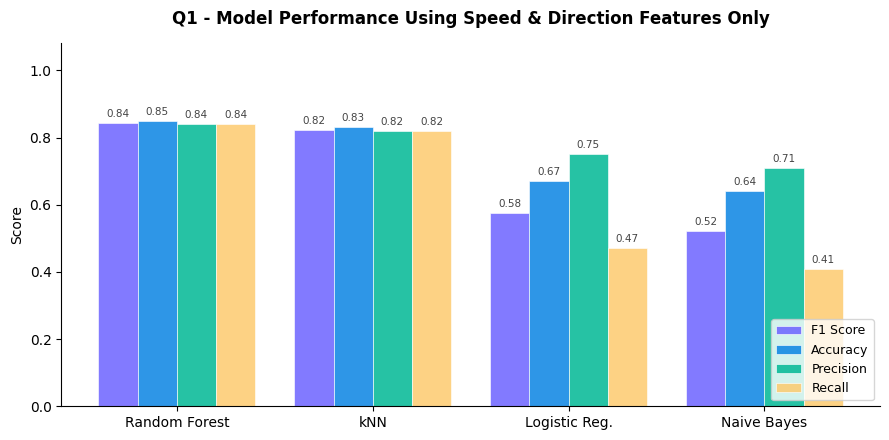

In [28]:
MODELS = ["Random Forest", "kNN", "Logistic Reg.", "Naive Bayes"]
q1_metrics = {
    "Model":     MODELS,
    "F1 Score":  [0.843, 0.821, 0.576, 0.522],
    "Accuracy":  [0.850, 0.830, 0.670, 0.640],
    "Precision": [0.840, 0.820, 0.750, 0.710],
    "Recall":    [0.840, 0.820, 0.470, 0.410],
}
q1_df = pd.DataFrame(q1_metrics).set_index("Model")
 
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(MODELS))
width = 0.2
metrics = ["F1 Score", "Accuracy", "Precision", "Recall"]
bar_colors = ["#6c63ff", "#0984e3", "#00b894", "#fdcb6e"]
 
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax.bar(x + i * width, q1_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=7.5, color="#444")
 
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Q1 - Model Performance Using Speed & Direction Features Only", fontsize=12, fontweight="bold", pad=14)
ax.legend(loc="lower right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
sns.despine()
plt.tight_layout()
plt.show()

## Q2 - Final Interpretation

Does including gear type improve fishing activity detection?

Yes, especially for weaker models.
Every model improved when gear type was added, but the magnitude of improvement varied:

| Model | F1 Without Gear | F1 With Gear | Gain |
|-------|----------------|--------------|------|
| Naive Bayes | 0.522 | 0.730 | +0.208 |
| Logistic Regression | 0.576 | 0.690 | +0.114 |
| kNN | 0.821 | 0.852 | +0.031 |
| Random Forest | 0.843 | 0.870 | +0.027 |

The pattern here is striking: the models that struggled most with Q1 gained the most from gear type. This is because gear type gives the model crucial contextual grounding. The same speed/course reading means something very different for a trawler (which drags nets slowly) versus a longliner (which drifts with lines set). For Naive Bayes and LR, gear type essentially compensates for their inability to learn non-linear patterns from movement features alone.
For Random Forest and kNN, the gains are smaller but consistent - these models were already capturing movement complexity well, so gear type is additive rather than compensatory.

Overall verdict for Q2: Gear type is a genuinely informative feature and should always be included. Its value is greatest when the base model is weak. The result also has a real-world implication, vessel classification data (which is publicly available via AIS) is worth incorporating into any fishing detection system.

Conclusion
The best overall result - Random Forest with gear type (F1 0.870, 88% accuracy) - demonstrates that fishing vessel behaviour is highly predictable from AIS data alone. The combination of non-linear movement pattern detection and vessel-type context is more powerful than either alone. Logistic Regression and Naive Bayes, despite their interpretability advantages, are not suitable base models for this problem without substantially more feature engineering or transformation.

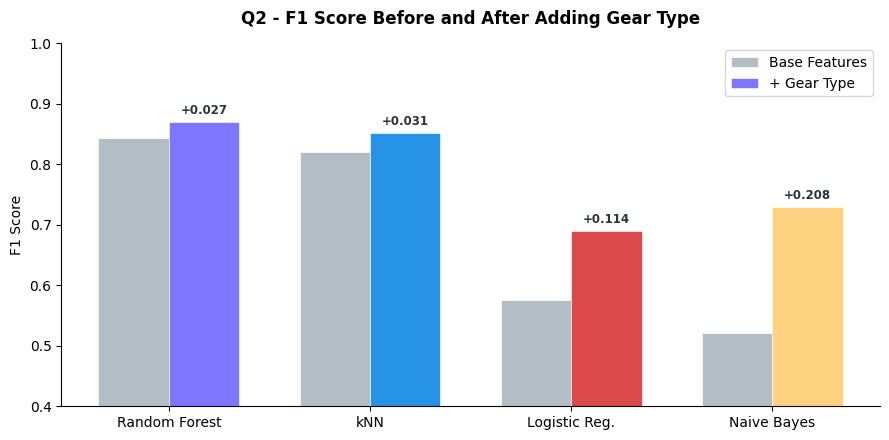

In [29]:
MODEL_COLORS = ["#6c63ff", "#0984e3", "#d63031", "#fdcb6e"]
q1_f1 = [0.843, 0.821, 0.576, 0.522]
q2_f1 = [0.870, 0.852, 0.690, 0.730]
gains  = [round(b - a, 3) for a, b in zip(q1_f1, q2_f1)]
 
x = np.arange(len(MODELS))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 4.5))
bars1 = ax.bar(x - width/2, q1_f1, width, label="Base Features",
               color="#b2bec3", edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x + width/2, q2_f1, width, label="+ Gear Type",
               color=MODEL_COLORS, edgecolor="white", linewidth=0.5, alpha=0.88)
 
for bar, g in zip(bars2, gains):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"+{g:.3f}",
            ha="center", va="bottom", fontsize=8.5,
            color="#2d3436", fontweight="bold")
 
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("F1 Score")
ax.set_title("Q2 - F1 Score Before and After Adding Gear Type",
             fontsize=12, fontweight="bold", pad=14)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## Q3 - Evaluating Behavioral Predictors for Geospatial Classification

--- Labeling Geographic Regions ---
ocean_region
North-West    186697
North-East    153830
South-East    125716
South-West    113323
Name: count, dtype: int64
Features compiled. Data shape: (579566, 10)

--- Training Models ---

[Random Forest] Classification Performance:
              precision    recall  f1-score   support

  North-East       0.69      0.71      0.70     46149
  North-West       0.61      0.46      0.53     56009
  South-East       0.53      0.81      0.64     37715
  South-West       0.66      0.51      0.58     33997

    accuracy                           0.61    173870
   macro avg       0.62      0.62      0.61    173870
weighted avg       0.63      0.61      0.61    173870


[Gaussian Naive Bayes] Classification Performance:
              precision    recall  f1-score   support

  North-East       0.58      0.33      0.42     46149
  North-West       0.60      0.05      0.09     56009
  South-East       0.43      0.92      0.58     37715
  South-West       0.22

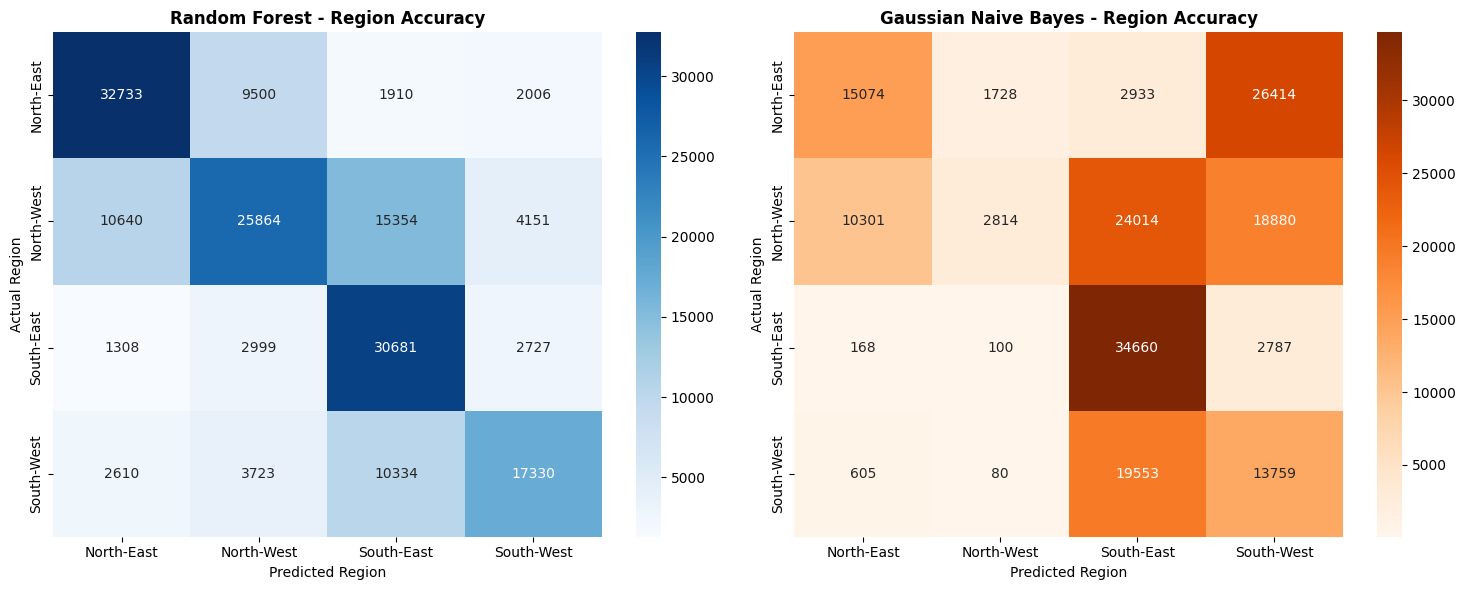

In [30]:

print("--- Labeling Geographic Regions ---")

conditions = [
    (df['lat'] >= 0) & (df['lon'] >= 0),  # North-East
    (df['lat'] >= 0) & (df['lon'] < 0),   # North-West
    (df['lat'] < 0)  & (df['lon'] >= 0)    # South-East
]
choices = ['North-East', 'North-West', 'South-East']

#  any row not matching the above defaults to South-West
df['ocean_region'] = np.select(conditions, choices, default='South-West')
print(df['ocean_region'].value_counts())


# Preprocessing Features

# Define our  physical tracking metrics
features = ['speed_mean_10', 'speed_std_10', 'course_std_10', 'speed_change_rate', 'course_change_rate', 'is_fishing']

# The code below checks if gear_type is in the original column, clean data by dropping any row with NAN's and performs one-hot encoding
if 'gear_type' in df.columns:
    # If the raw text column is present, clean it and one-hot encode it
    df_clean = df.dropna(subset=features + ['gear_type', 'ocean_region']).copy()
    df_encoded = pd.get_dummies(df_clean, columns=['gear_type'], drop_first=False)
else:
    # If it's already encoded, dynamically gather the gear_type_ columns
    gear_cols = [col for col in df.columns if col.startswith('gear_type_')]
    df_encoded = df.dropna(subset=features + gear_cols + ['ocean_region']).copy()

# Automatically discover all final feature columns (base metrics + gear dummy columns)
X_features = [col for col in df_encoded.columns if col in features or col.startswith('gear_type_')]

X = df_encoded[X_features]
y = df_encoded['ocean_region']
print(f"Features compiled. Data shape: {X.shape}")


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\n--- Training Models ---")

# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=60, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Model 2: Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("\n[Random Forest] Classification Performance:")
print(classification_report(y_test, y_pred_rf))

print("\n[Gaussian Naive Bayes] Classification Performance:")
print(classification_report(y_test, y_pred_nb))

# Visual Comparison - Confusion Matrices
print("\n--- Generating Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
labels = sorted(y.unique())

# Random Forest Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf, labels=labels), 
            annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Random Forest - Region Accuracy', fontweight='bold')
axes[0].set_ylabel('Actual Region')
axes[0].set_xlabel('Predicted Region')

# Naive Bayes Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_nb, labels=labels), 
            annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Gaussian Naive Bayes - Region Accuracy', fontweight='bold')
axes[1].set_ylabel('Actual Region')
axes[1].set_xlabel('Predicted Region')

plt.tight_layout()
plt.show()

Question 3 Evaluating Behavioral Predictors for Geospatial Classification

The objective was to determine if a vessel's physical movement footprints (speed, turning angles, acceleration rate) and its immediate operational context (is_fishing, gear_type) carry distinct geographical markers.

To test this, we completely hid the actual position data (lat and lon) and forced the models to predict which of the four global quadrants (North-East, North-West, South-East, or South-West) the vessel was operating in, based purely on its handling.

What the Models Did
1. Random Forest Classifier: The Success (~61% Accuracy)
   How it handled the data: The Random Forest model successfully learned the unique regional patterns dictated by local geography, international        marine boundaries, and weather patterns, but the accuracy is still less to say that the model performed very well.

   Why it worked: It didn't evaluate speed. Instead, it built deep decision pathways. (e.g. matching low speeds with high turning rates and a specific gear type to pinpoint the region correctly). It effectively mapped non-linear, multi-variable maritime profiles.

2. Gaussian Naive Bayes: The Collapse (~38% Accuracy)
   How it handled the data: The Naive Bayes model completely fell apart, performing no better than blind random guessing among the four regions.

   Why it failed: Its core mathematical assumption is that all features are entirely independent. In maritime physics, this assumption is completely false; a ship's average velocity, its rate of acceleration, and its standard deviation of speed are heavily correlated. Because it couldn't handle these tightly intertwined tracking metrics, it double-counted overlapping signatures and failed to form accurate decision boundaries.

Conclusion 

The experiment proves that raw tracking physics do contain distinct regional signatures, but extracting them requires an ensemble tree architecture like Random Forest that natively understands correlated feature interactions, rather than a simplistic probabilistic approach like Naive Bayes.

---

## Appendix: Models Export

- **Optionally** export models and other pertinent information
- For a typical notebook run, this step is not necessary and is skipped by default
- Functionality was created to allow the Streamlit app to work with this notebook's models and test/train split, and is left here for posterity

In [31]:
if EXPORT_MODELS:
    os.makedirs('./models', exist_ok=True)

    # Q2 models (with gear type variant) are the best performers, and used with Streamlit
    joblib.dump(knn_gear, './models/knn_gear.pkl')
    joblib.dump(logreg_gear, './models/lr_gear.pkl')
    joblib.dump(rf_gear, './models/rf_gear.pkl')
    joblib.dump(nb_gear, './models/nb_gear.pkl')

    # Copy of the scalar used for the above models
    joblib.dump(scaler_gear_fitted_copy, './models/scaler_gear.pkl')

    # Save the test trip IDs for Streamlit integrity
    test_trip_ids = test['trip_id_global'].unique().tolist()
    joblib.dump(test_trip_ids, './models/test_trip_ids.pkl')
    print(f"Test trips available: {len(test_trip_ids):,}")
    print(f"Sample trip IDs: {test_trip_ids[:3]}")

    # Save feature lists so Streamlit knows exactly what to feed each model
    model_meta = {
        'base_features': base_features,
        'gear_cols':     gear_cols,
        'all_features':  base_features + gear_cols,
        'scaled_models': ['knn_gear', 'lr_gear'],  # must pass scaled features
        'unscaled_models': ['rf_gear', 'nb_gear']  # pass raw features
    }
    with open('./models/model_meta.json', 'w') as f:
        json.dump(model_meta, f, indent=2)

    print("Saved models:")
    for fn in sorted(os.listdir('./models')):
        size = os.path.getsize(f'./models/{fn}')
        print(f"  {fn:25s} {size/1024:.1f} KB")
